In [1]:
%matplotlib inline 

In [3]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_custom_stf_weighted" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# # Add code to keep .gitignore updated to ignore salvus files
# gitignore_path = pathlib.Path("..") / ".gitignore"
# with open(gitignore_path, "r+") as f:
#     contents = f.read()
#     if PROJECT_DIR not in contents:
#         f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import salvus.flow.simple_config as sc
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output
import salvus.flow.api

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.21 seconds]


In [4]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

Time step between sources: 0.5556 s
t_sim length: 28823 samples, duration: 2.882 s
Source 0 at x=30.0 m | delay=0.0800 s | weight=1.9352 | stf_start_time=0.000000s


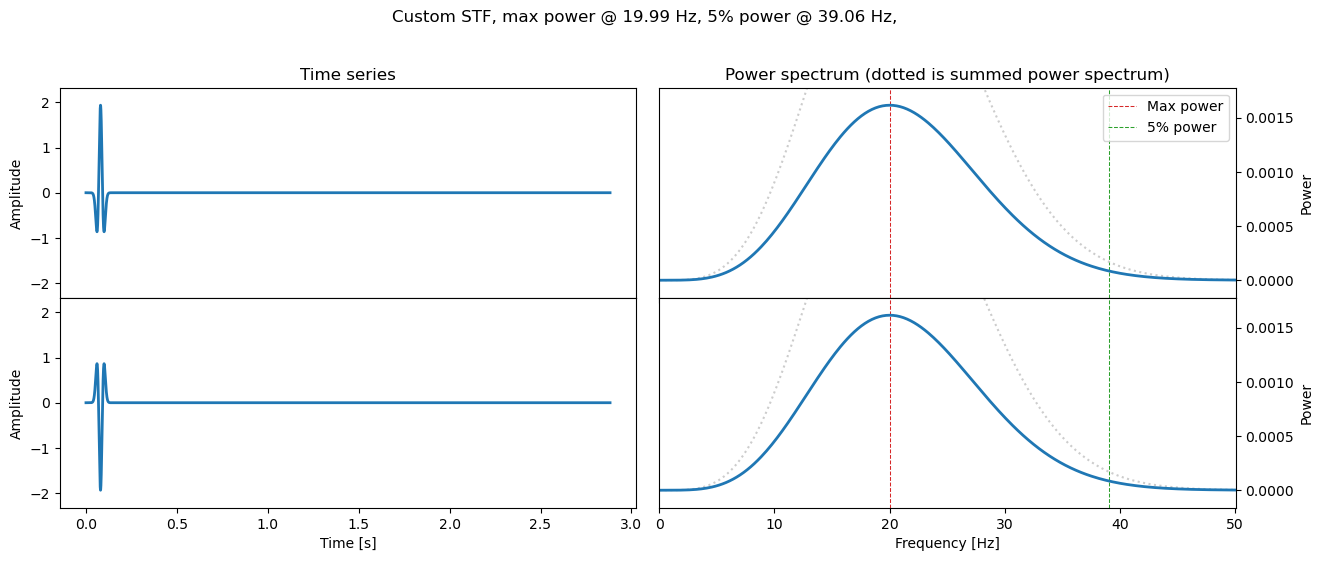

Plotting source index 0 at x = 30.0 m (delay = 0.0800 s, weight = 1.9352):


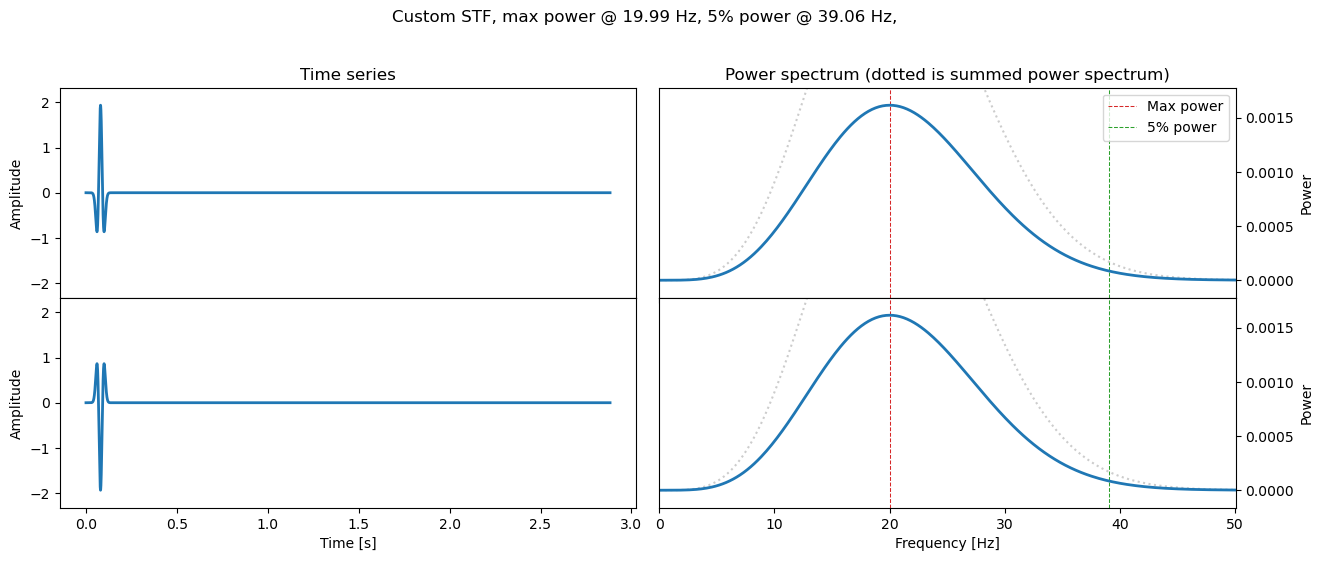

Plotting source index 1 at x = 80.0 m (delay = 0.6356 s, weight = 4.7585):


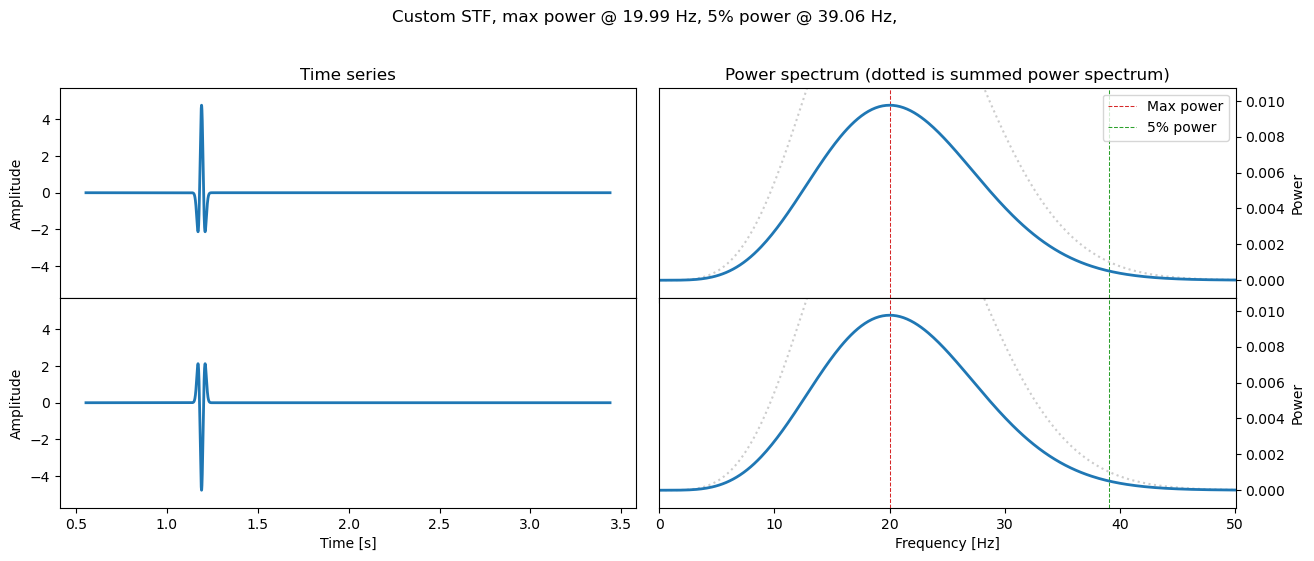

Plotting source index 2 at x = 130.0 m (delay = 1.1911 s, weight = 3.6868):


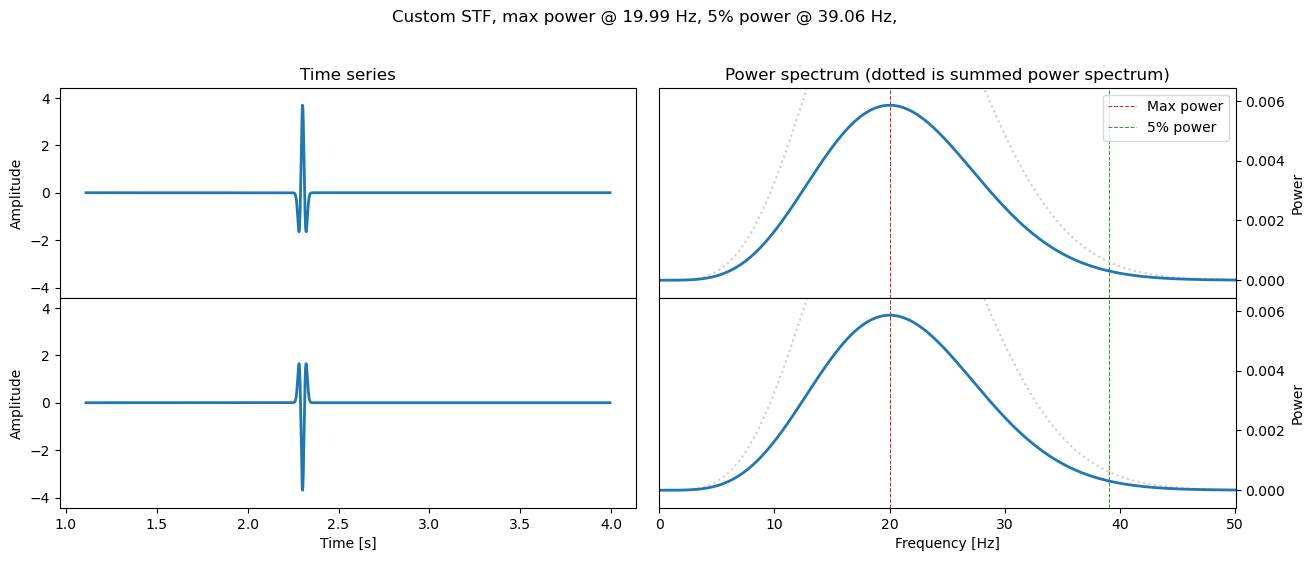

Plotting source index 3 at x = 180.0 m (delay = 1.7467 s, weight = 3.0334):


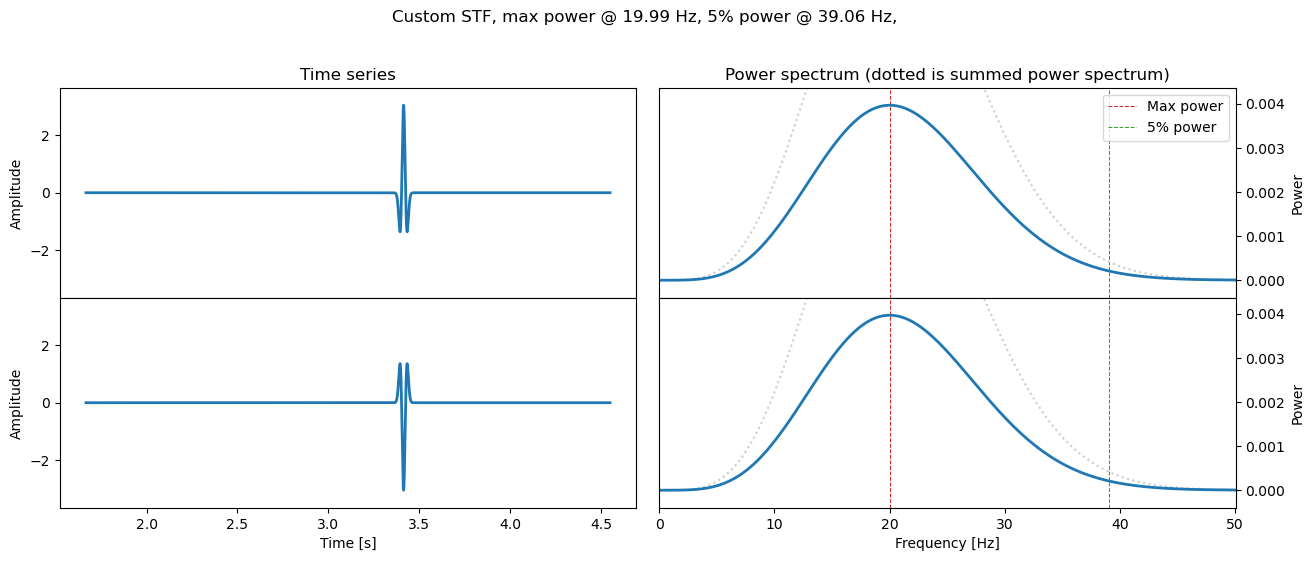

Plotting source index 4 at x = 230.0 m (delay = 2.3022 s, weight = 0.8645):


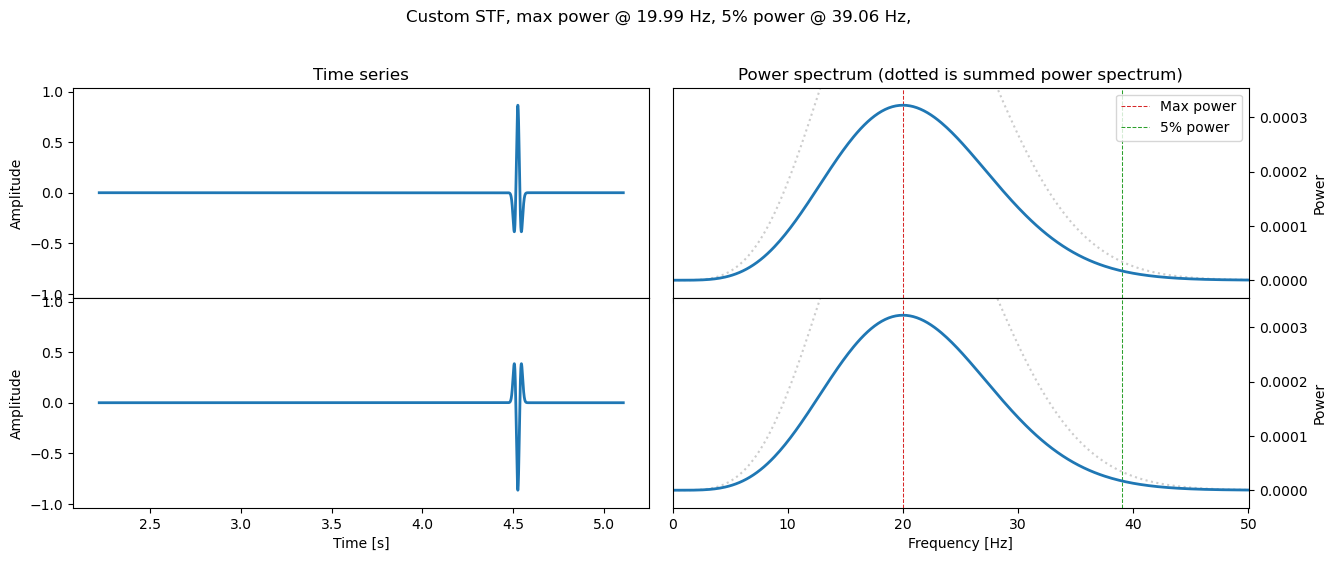


Generated 5 sources.
First source centred at: 0.0800 s
Last  source centred at: 2.3022 s


In [8]:
np.random.seed(42)

# Simulation constants
f0 = 20.0
sampling_rate = 10000.0
dt = 1.0 / sampling_rate

step = 50
x_positions = np.arange(30.0, 270.0, step)
target_vprop = 90.0
delay_between_sources = step / target_vprop
print(f"Time step between sources: {delay_between_sources:.4f} s")

y_src = 2.625

# Pre-delay: shifts ALL sources forward so source 0 has full room
wavelet_half_width = 0.08
pre_delay = wavelet_half_width  # 0.08 s — first wavelet centred at 0.08 s

# Extend t_max to accommodate pre_delay + all source delays + trailing room
last_source_delay = (len(x_positions) - 1) * delay_between_sources
t_max = pre_delay + last_source_delay + wavelet_half_width + 0.5
t_sim = np.arange(0, t_max, dt)
print(f"t_sim length: {len(t_sim)} samples, duration: {t_sim[-1]:.3f} s")

# Base Ricker wavelet on symmetric local time axis
t_local = np.arange(-wavelet_half_width, wavelet_half_width, dt)
wavelet_base = (
    (1.0 - 2.0 * (np.pi * f0 * t_local) ** 2)
    * np.exp(-((np.pi * f0 * t_local) ** 2))
)
half_samples = len(wavelet_base) // 2

base_fx =  1.0
base_fy = -1.0

srcs = []

for i, x_src in enumerate(x_positions):
    # Every source gets pre_delay + its propagation delay — no special cases
    center_time = pre_delay + i * delay_between_sources
    center_sample = int(round(center_time * sampling_rate))

    start_idx = center_sample - half_samples
    end_idx = center_sample + half_samples

    wavelet_delayed = np.zeros(len(t_sim))

    if end_idx > 0 and start_idx < len(t_sim):
        sim_start = max(0, start_idx)
        sim_end = min(len(t_sim), end_idx)
        wav_start = max(0, -start_idx)
        wav_end = wav_start + (sim_end - sim_start)
        wavelet_delayed[sim_start:sim_end] = wavelet_base[wav_start:wav_end]

    # Sanity check: full wavelet should be contained
    n_nonzero = np.count_nonzero(wavelet_delayed)
    expected = len(wavelet_base)
    if n_nonzero < expected - 2:
        print(f"  WARNING source {i}: only {n_nonzero}/{expected} samples written — wavelet clipped!")

    random_weight = np.random.uniform(0.1, 5.0)

    stf_vector_array = np.array([
        wavelet_delayed * (base_fx * random_weight),
        wavelet_delayed * (base_fy * random_weight),
    ])

   
    stf_start_time = start_idx * dt  # This tells Salvus when the wavelet actually starts

    stf = sc.stf.Custom.from_array(
        array=stf_vector_array,
        sampling_rate_in_hertz=sampling_rate,
        start_time_in_seconds=stf_start_time,  # Use the absolute start time
    )

    plotting_steps = np.arange(0, len(x_positions), 5)
    if i in plotting_steps:
        print(f"Source {i} at x={x_src:.1f} m | delay={pre_delay + i*delay_between_sources:.4f} s | weight={random_weight:.4f} | stf_start_time={stf_start_time:.6f}s")
        stf.plot()
        display(plt.gcf())
        plt.close()

    src = sc.source.cartesian.VectorPoint2D(
        x=x_src,
        y=y_src,
        fx=1.0,
        fy=1.0,
        source_time_function=stf,
    )
    srcs.append(src)


    # Plotting every 100th source for visual inspection of the STF
    plotting_steps = np.arange(0, len(x_positions), 1)
    if i in plotting_steps:
        print(f"Plotting source index {i} at x = {x_src:.1f} m (delay = {pre_delay + i * delay_between_sources:.4f} s, weight = {random_weight:.4f}):")
        stf.plot()
        fig = plt.gcf()
        display(fig)
        plt.close(fig)

print(f"\nGenerated {len(srcs)} sources.")
print(f"First source centred at: {pre_delay:.4f} s")
print(f"Last  source centred at: {pre_delay + (len(srcs)-1)*delay_between_sources:.4f} s")